In [1]:
# Backend
import os

os.environ["KERAS_BACKEND"] = "jax"

In [2]:
# Setup
import json
from importlib import import_module
from pathlib import Path
from typing import cast

import numpy as np
import pandas as pd

from src.callbacks import ImportanceUpdate
from src.models import LearnableCutFlowModel, LearnableCutFlowSequentialModel
from src.utils import (
    Timer,
    load_model,
    plot_learned_cut,
    plot_learned_importance,
    print,
    tex_to_str,
    to_numpy,
)

In [3]:
# Parameters
rerun = True

# Config
with open("1-dataset:config.json", "r") as f:
    dataset_config = json.load(f)

with open("2-model:config.json", "r") as f:
    model_config = json.load(f)

# Dataset
dataset = "mock1"  # * (mock1, mock2, mock3, mock4, mock5, mock6, real1)
features = dataset_config[dataset]["features"]
n_samples = dataset_config[dataset]["n_samples"]
seed = dataset_config[dataset]["seed"]

# Model
model = "lcf_par"  # * (lcf_par, lcf_seq)
model_builder = model_config[model]["model_builder"]
centers = model_config[model]["centers"][dataset]
n_epochs = model_config[model]["n_epochs"]
batch_size = model_config[model]["batch_size"]

# Figure
bins = dataset_config[dataset]["bins"]
if dataset == "real1":
    bins_t = [np.linspace(**kwargs) for kwargs in bins]
else:
    bins_t = [np.linspace(**bins)] * len(features)

# Path
prefix = f"3-dataset:{dataset}-model:{model}"
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")

# Results
if rerun:
    results = {}
else:
    with open(RESULTS_DIR / f"{prefix}-results.json", "r") as f:
        results = json.load(f)

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset}")
load_data = getattr(module, "load_data")

if dataset == "mock6":
    (x_train, y_train), (x_test, y_test), order = load_data(n_samples, seed)
    features = [features[i] for i in order]
else:
    (x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 4)
y_train.shape=(100000, 1)
x_test.shape=(100000, 4)
y_test.shape=(100000, 1)


In [ ]:
# Model
if rerun:
    ModelBuilder = getattr(import_module("src.models"), model_builder)
    model_t = ModelBuilder(
        input_shape=x_train.shape,
        centers=centers,
        features=features,
        name=model,
    )
    model_t = cast(LearnableCutFlowModel, model_t)
    model_t.adapt(x_train)
    model_t.compile(optimizer="adam", loss="crossentropy")

    with Timer() as timer:
        model_t.fit(
            x_train,
            y_train,
            batch_size=batch_size,
            epochs=n_epochs,
            callbacks=[ImportanceUpdate(model_t)],
            verbose=2,
        )

    file_path = CHECKPOINTS_DIR / f"{prefix}-checkpoint.keras"
    model_t.save(file_path)

    results.update(
        {
            "file_path": file_path.as_posix(),
            "training_time": timer.record,
        }
    )

checkpoint = load_model(results["file_path"])
checkpoint = cast(LearnableCutFlowModel, checkpoint)

print(f"Training time: {results['training_time']:.2f} seconds")

Epoch 1/200
196/196 - 4s - 20ms/step - loss: 0.3182
Epoch 2/200
196/196 - 1s - 6ms/step - loss: 0.3037
Epoch 3/200
196/196 - 0s - 888us/step - loss: 0.2941
Epoch 4/200
196/196 - 0s - 826us/step - loss: 0.2872
Epoch 5/200
196/196 - 0s - 863us/step - loss: 0.2820
Epoch 6/200
196/196 - 0s - 1ms/step - loss: 0.2776
Epoch 7/200
196/196 - 0s - 819us/step - loss: 0.2738
Epoch 8/200
196/196 - 0s - 786us/step - loss: 0.2703
Epoch 9/200
196/196 - 0s - 1ms/step - loss: 0.2670
Epoch 10/200
196/196 - 0s - 951us/step - loss: 0.2640
Epoch 11/200
196/196 - 0s - 991us/step - loss: 0.2612
Epoch 12/200
196/196 - 0s - 900us/step - loss: 0.2585
Epoch 13/200
196/196 - 0s - 1ms/step - loss: 0.2561
Epoch 14/200
196/196 - 0s - 1ms/step - loss: 0.2538
Epoch 15/200
196/196 - 0s - 881us/step - loss: 0.2516
Epoch 16/200
196/196 - 0s - 771us/step - loss: 0.2496
Epoch 17/200
196/196 - 0s - 771us/step - loss: 0.2478
Epoch 18/200
196/196 - 0s - 1ms/step - loss: 0.2460
Epoch 19/200
196/196 - 0s - 868us/step - loss: 0.2

In [7]:
# Analysis: metrics
if rerun:
    y_pred = checkpoint.predict(x_test, batch_size=batch_size, verbose=0)

    tp = np.sum((y_test == 1) & (y_pred == 1))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fn = np.sum((y_test == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)

    s = tp / (tp + tn + fp + fn) * 3000 * 1000 * 0.7644
    b = fp / (tp + tn + fp + fn) * 3000 * 1000 * 1.806 * 1e5
    significance = s / np.sqrt(b)

    results.update(
        {
            "tp": tp.tolist(),
            "fp": fp.tolist(),
            "accuracy": accuracy.tolist(),
            "precision": precision.tolist(),
            "significance": significance.tolist(),
        }
    )

print(f"True positive..{results['tp']:.>10}")
print(f"False positive.{results['fp']:.>10}")
print(f"Accuracy.......{results['accuracy']:.>10.4f}")
print(f"Precision......{results['precision']:.>10.4f}")
print(f"Significance...{results['significance']:.>10.4f}")

True positive.......25811
False positive.........34
Accuracy...........0.7592
Precision..........0.9987
Significance......43.6102


In [8]:
# Analysis: check metrics via learned cuts
mask = np.ones_like(x_test[:, 0], dtype="bool")

for i, cut in enumerate(checkpoint.cuts):
    if not checkpoint.importance.scores[i] > checkpoint.importance.baseline:  # type: ignore
        print(f"Ignored: {cut.expression}")
        continue

    x_i = x_test[:, i]
    if cut.case == 1:
        mask_i = x_i < cut.boundaries[cut.index]
    elif cut.case == 2:
        mask_i = x_i > cut.boundaries[cut.index]
    elif cut.case == 3:
        mask_i = np.logical_and(cut.boundaries[0] < x_i, x_i < cut.boundaries[1])
    else:
        mask_i = np.logical_or(x_i < cut.boundaries[0], cut.boundaries[1] < x_i)
    mask = np.logical_and(mask, mask_i)

y_pred_cut = mask.astype("float32")
y_pred_cut = np.reshape(y_pred_cut, y_test.shape)
tp = np.sum((y_test == 1) & (y_pred_cut == 1))
fp = np.sum((y_test == 0) & (y_pred_cut == 1))
tn = np.sum((y_test == 0) & (y_pred_cut == 0))
fn = np.sum((y_test == 1) & (y_pred_cut == 0))

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
significance = tp / np.sqrt(fp)

print(f"True positive..{tp:.>10}")
print(f"False positive.{fp:.>10}")
print(f"Accuracy.......{accuracy:.>10.4f}")
print(f"Precision......{precision:.>10.4f}")
print(f"Significance...{significance:.>10.4f}")

True positive.......25811
False positive.........34
Accuracy...........0.7592
Precision..........0.9987
Significance....4426.5500


In [9]:
# Analysis: learned cuts
if rerun:
    results["learned_cuts"] = [
        {
            "feature": cut.feature,
            "case": to_numpy(cut.case).tolist(),
            "index": to_numpy(cut.index).tolist(),
            "boundaries": to_numpy(cut.boundaries).tolist(),
            "directions": to_numpy(cut.directions).tolist(),
            "expression": cut.expression,
        }
        for cut in checkpoint.cuts
    ]

for learned_cut in results["learned_cuts"]:
    print(learned_cut["expression"])

$x_1$ < 0.0204
$x_2$ > -0.0057
-3.0598 < $x_3$ < 3.0422
$x_4$ < -3.0320 or $x_4$ > 3.0336


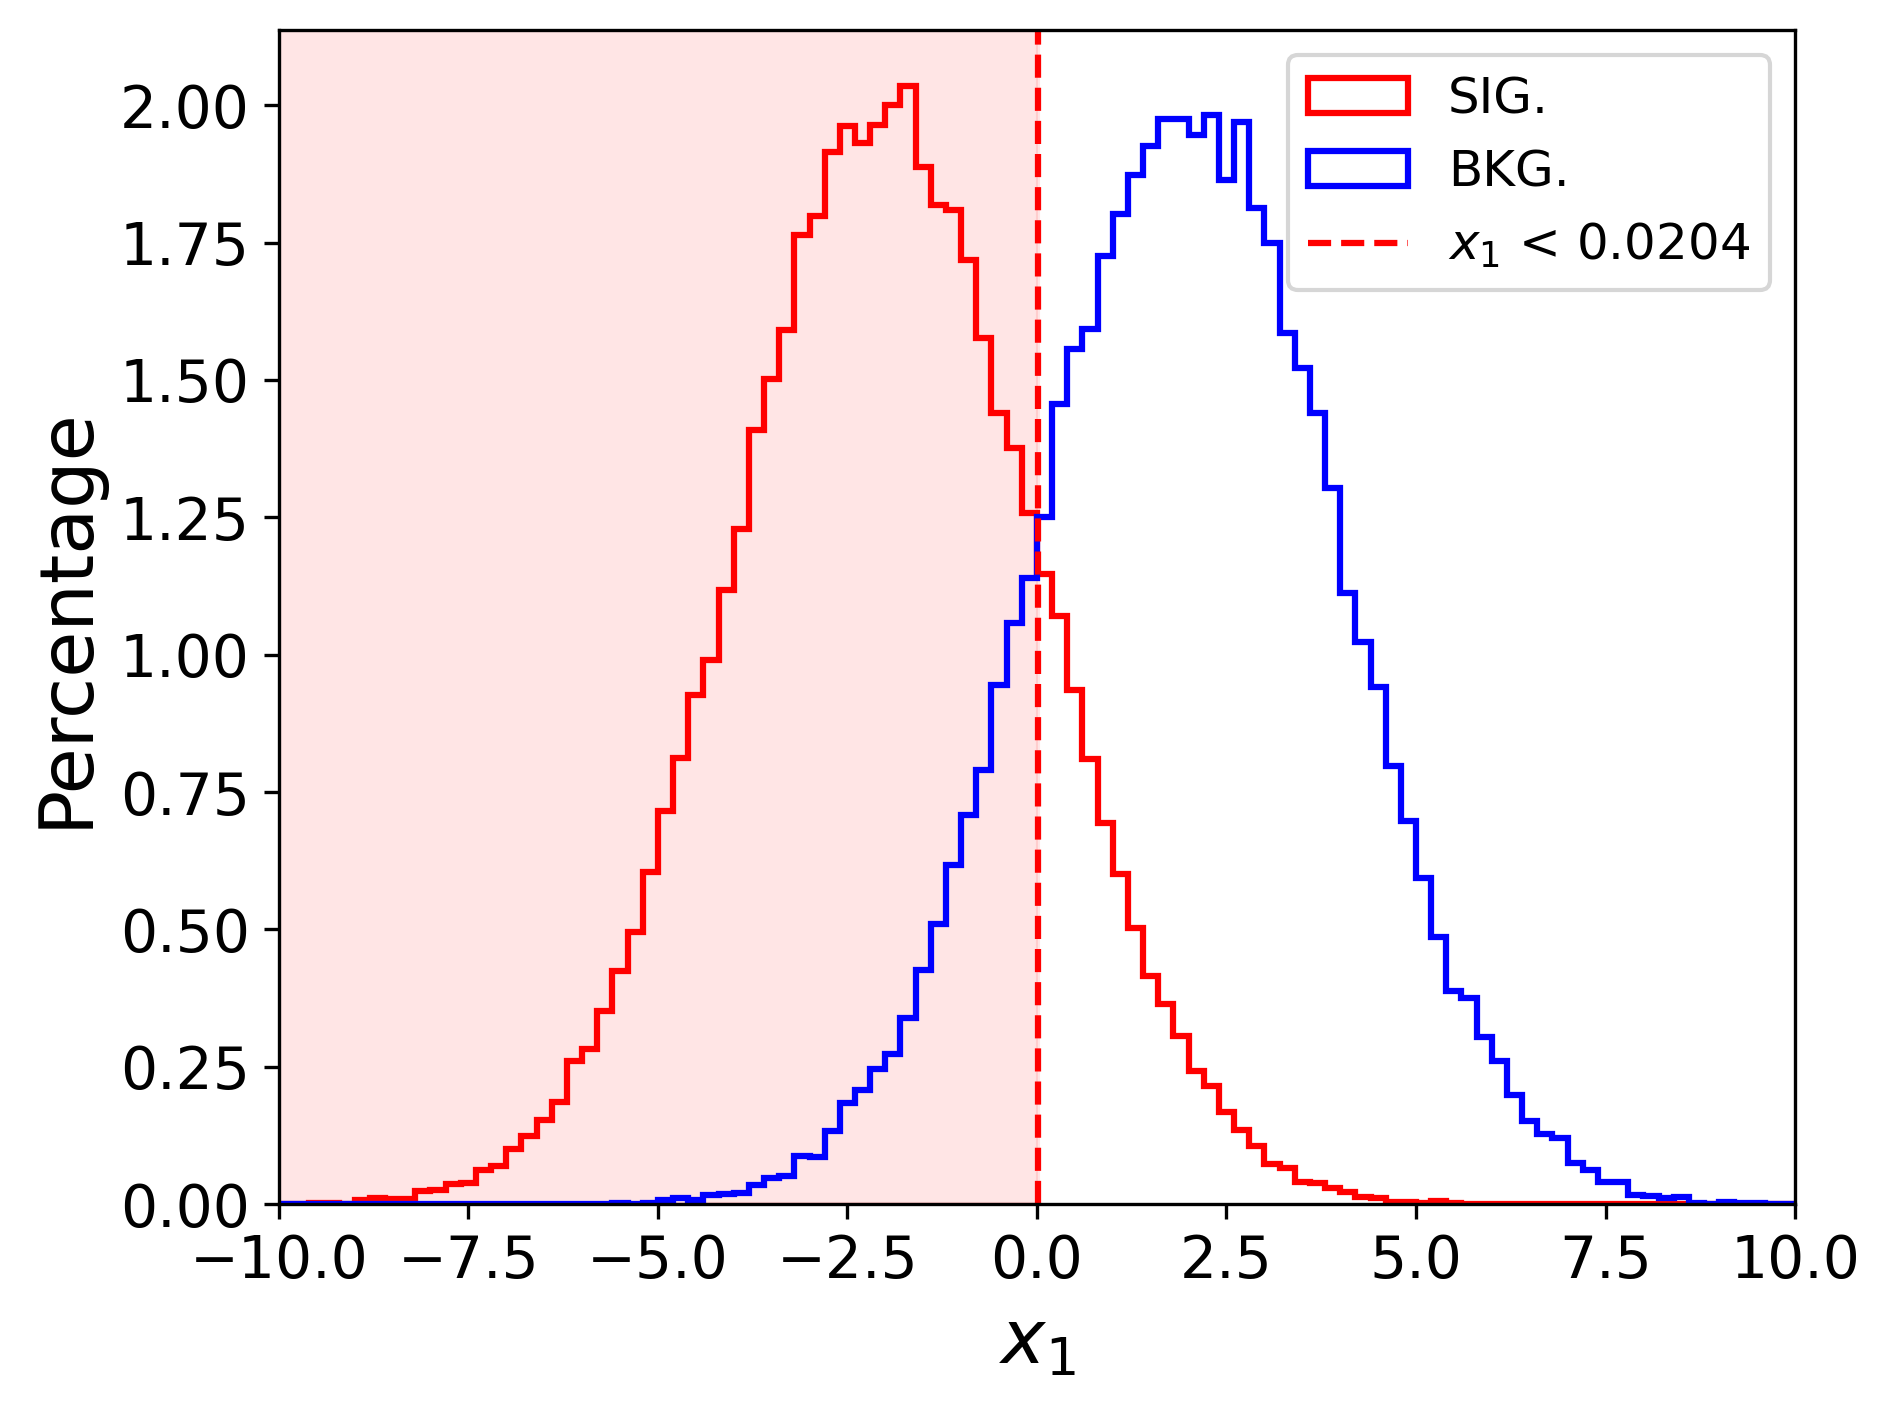

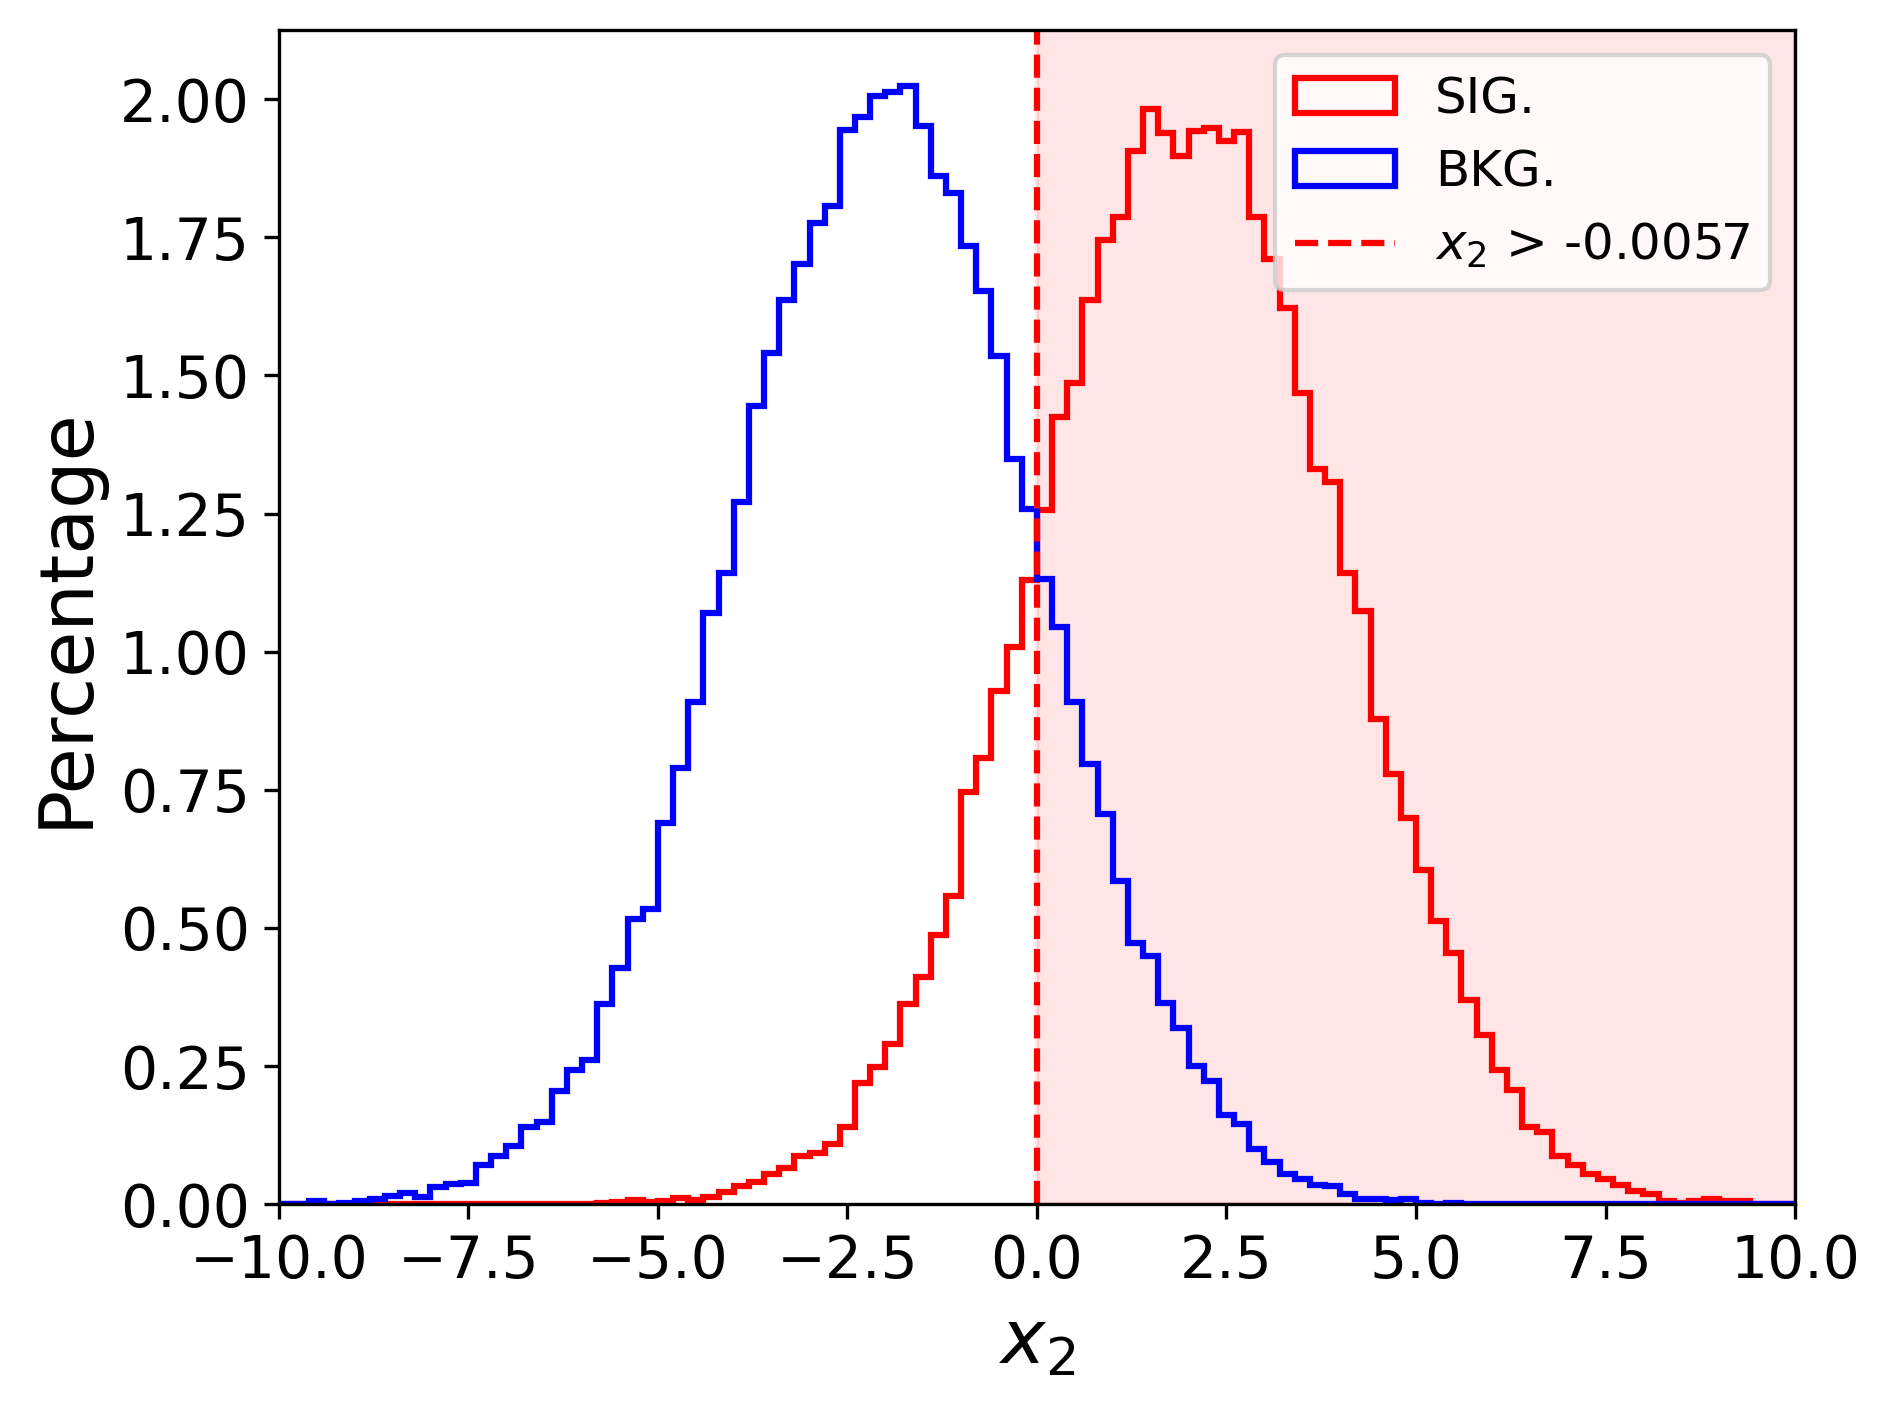

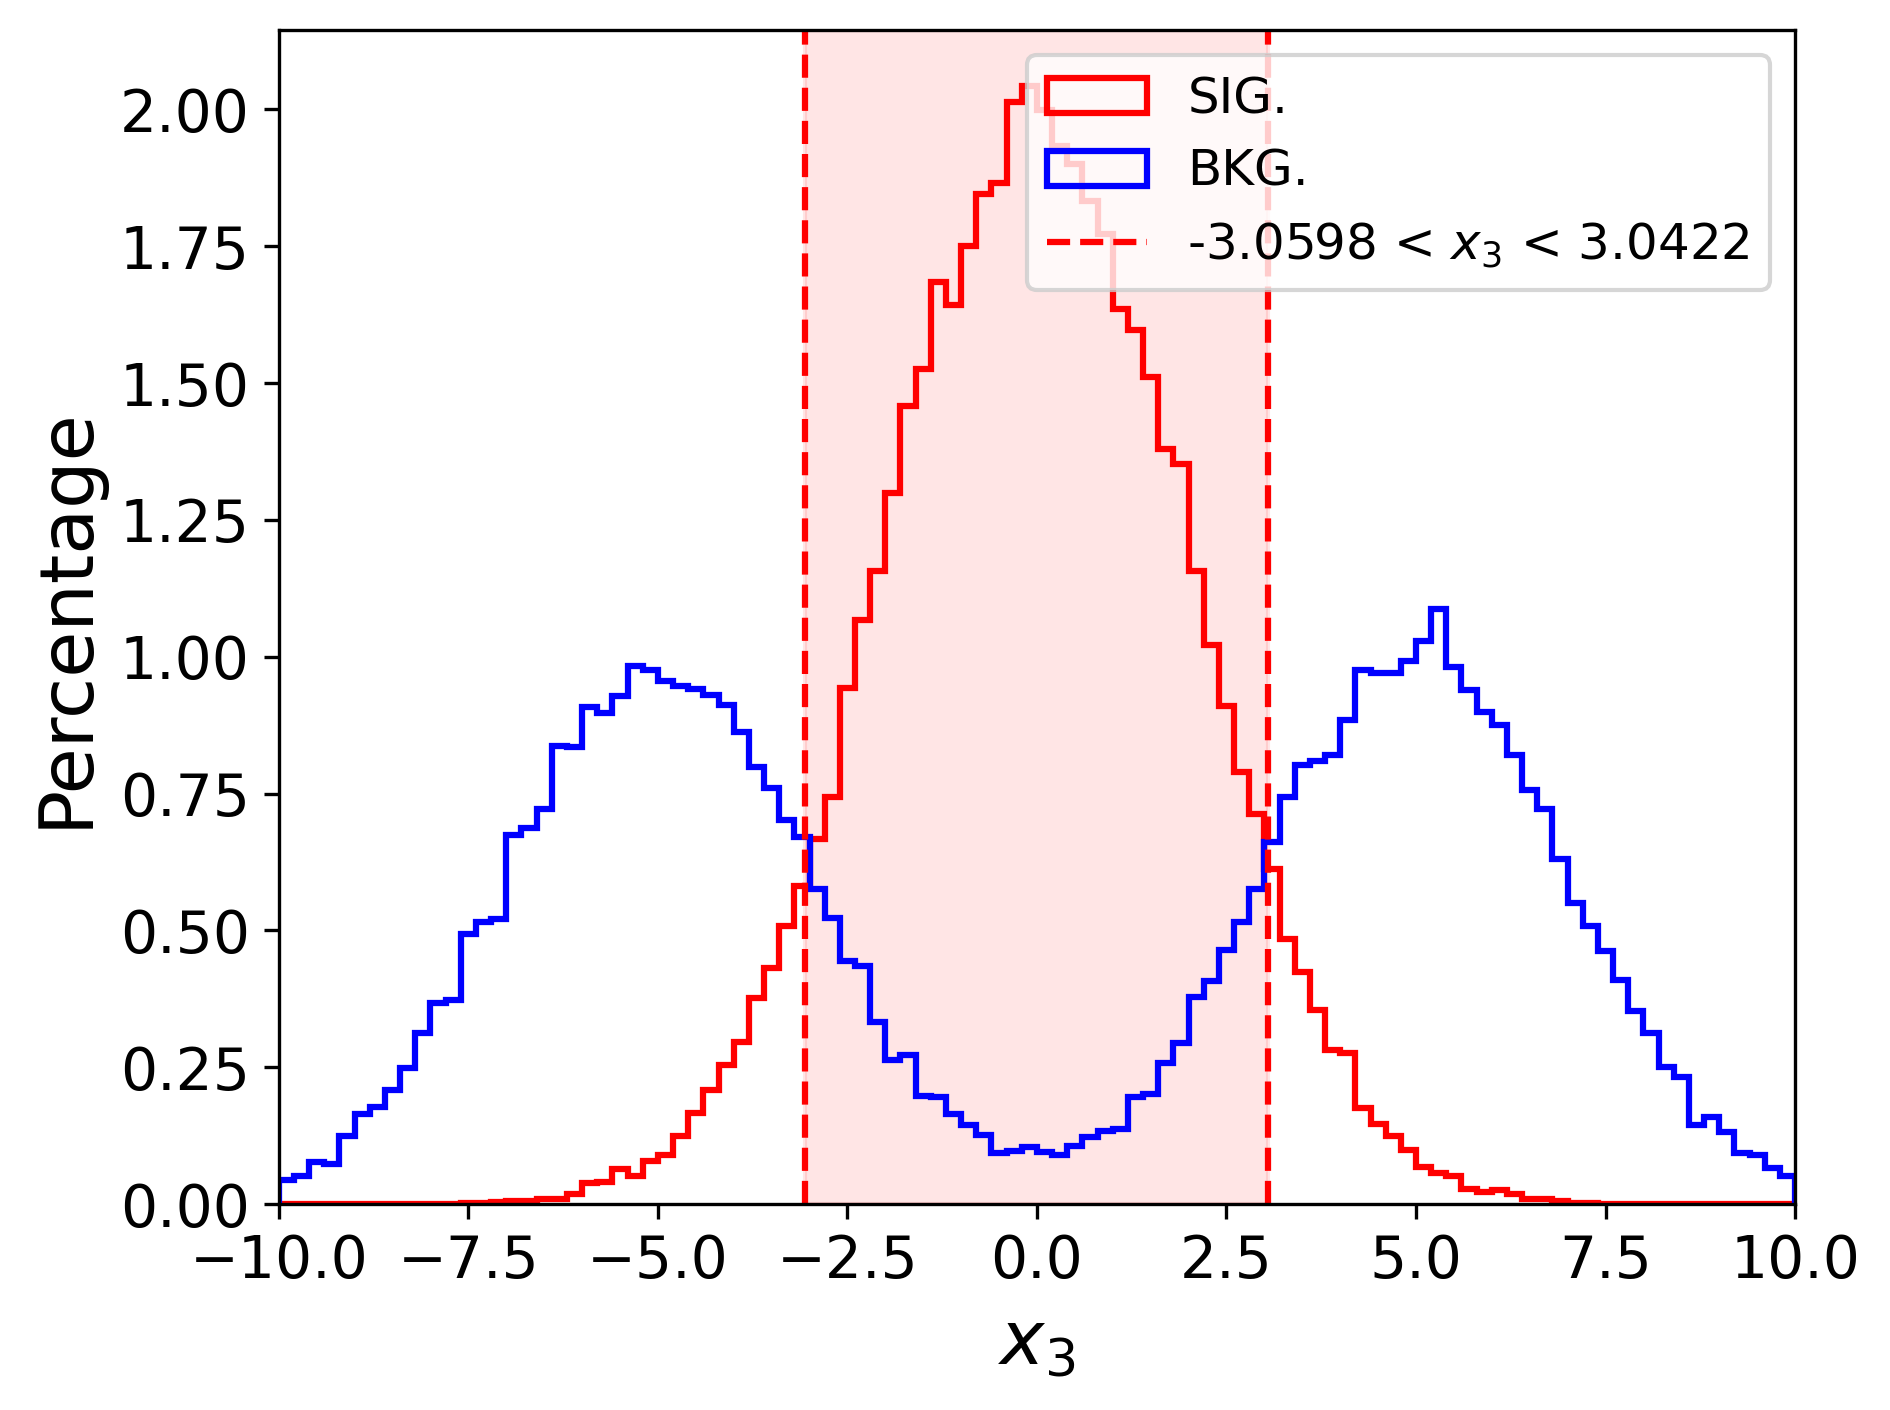

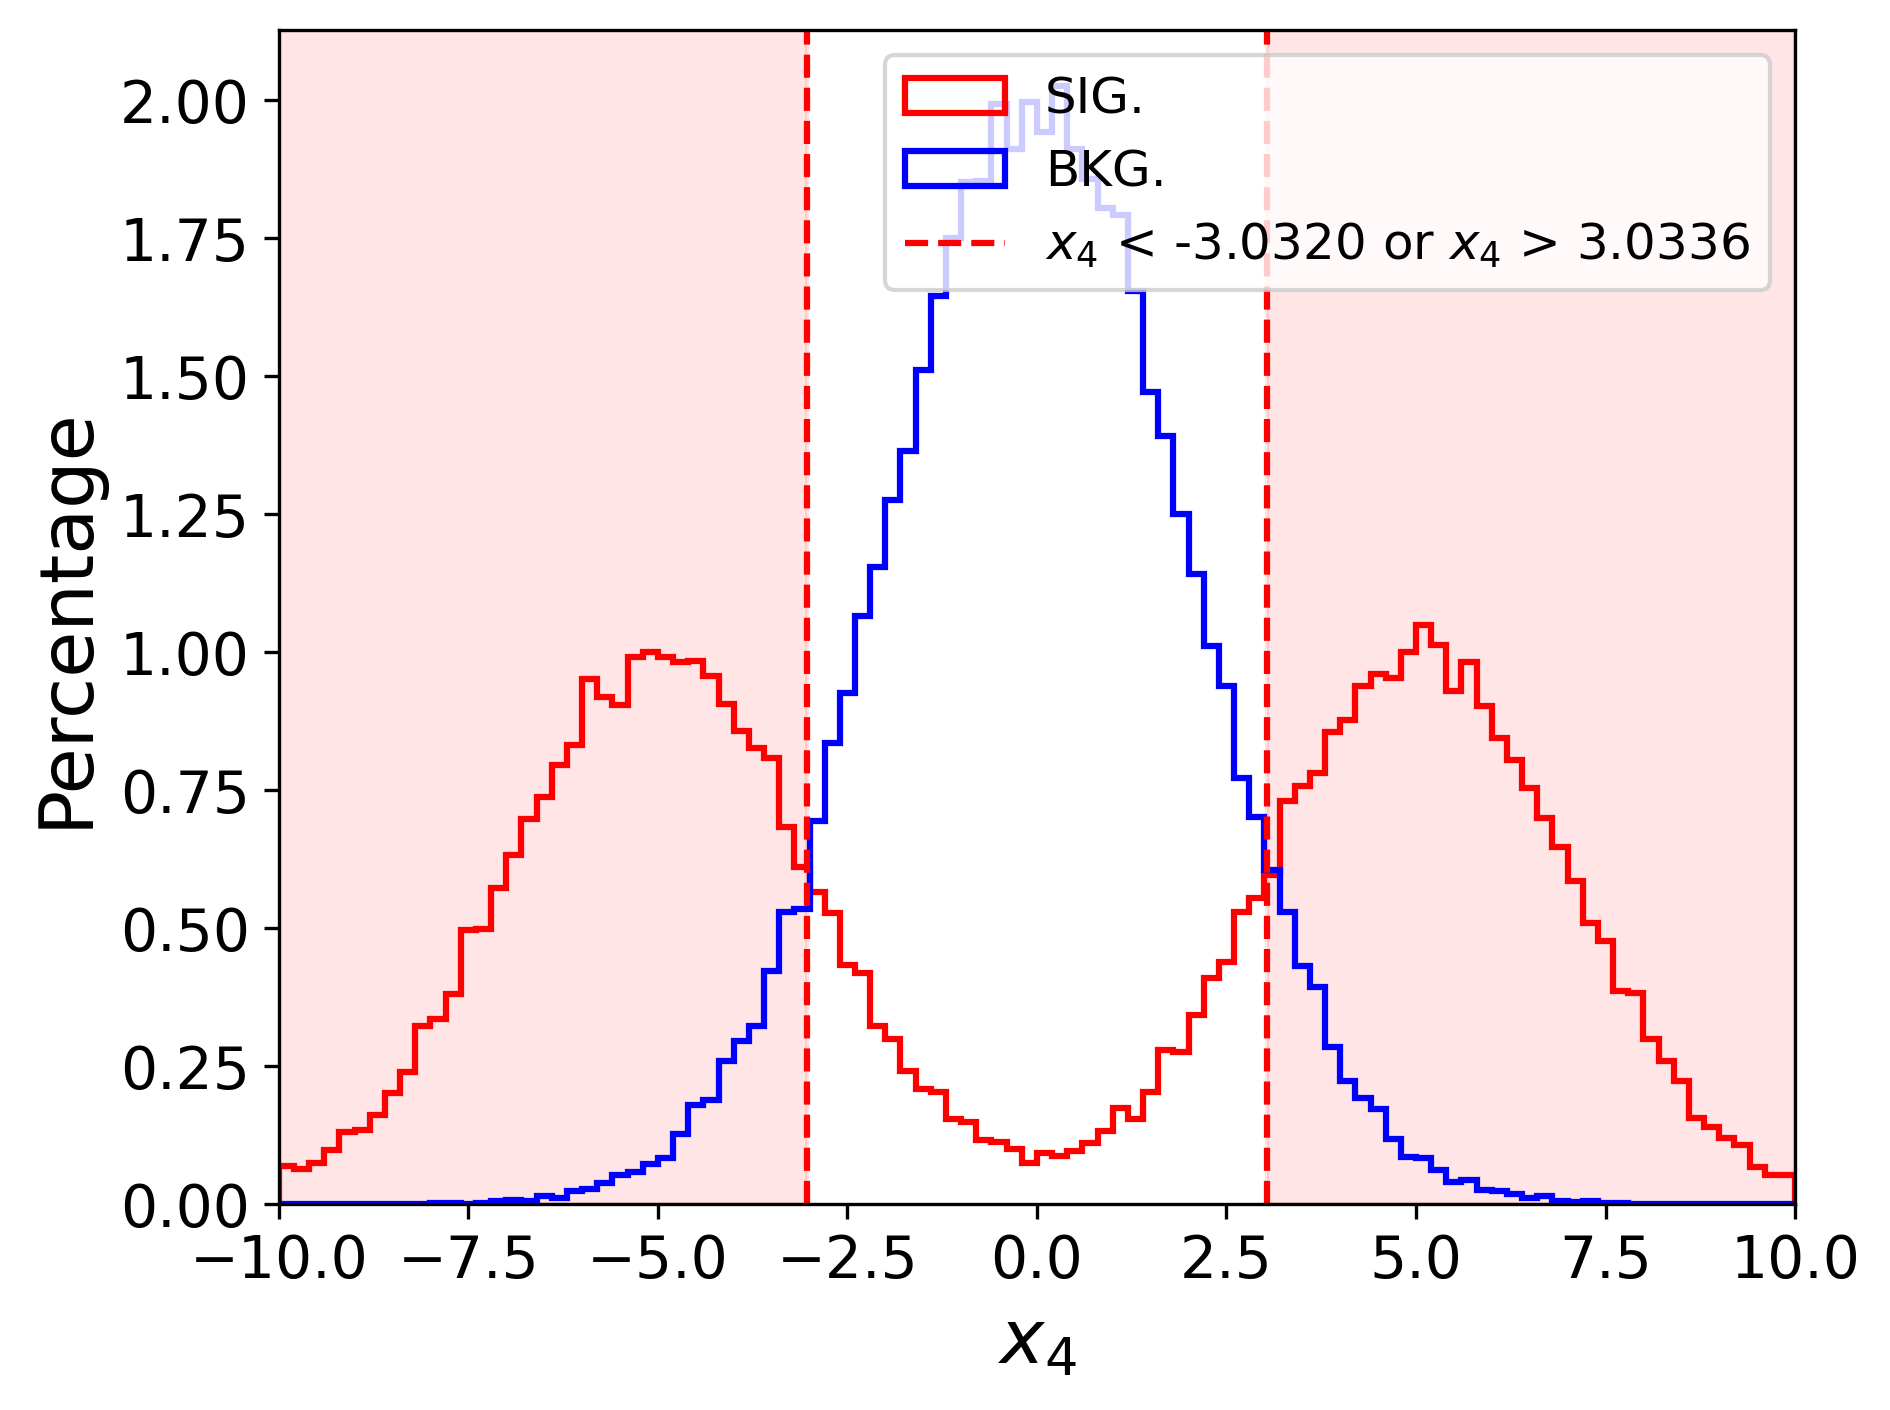

In [11]:
# Figure: learned cuts
learned_cuts = results["learned_cuts"]
features_str = [tex_to_str(feature) for feature in features]

df = pd.DataFrame(x_test, columns=features_str)
df["y"] = y_test.squeeze()

for i, feature in enumerate(features):
    sig = df.query("y == 1")[features_str[i]]
    bkg = df.query("y == 0")[features_str[i]]
    weights_sig = 100 * np.ones_like(sig) / len(df)
    weights_bkg = 100 * np.ones_like(bkg) / len(df)

    plot_learned_cut(
        case=learned_cuts[i]["case"],
        index=learned_cuts[i]["index"],
        boundaries=learned_cuts[i]["boundaries"],
        expression=learned_cuts[i]["expression"],
        data=[sig, bkg],
        bins=bins_t[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )
    plot_learned_cut(
        case=learned_cuts[i]["case"],
        index=learned_cuts[i]["index"],
        boundaries=learned_cuts[i]["boundaries"],
        expression=learned_cuts[i]["expression"],
        data=[sig, bkg],
        bins=bins_t[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{prefix}-learned_cut:{tex_to_str(feature)}.pdf",
    )

    if isinstance(checkpoint, LearnableCutFlowSequentialModel):
        cut_query = checkpoint.cuts[i].expression.replace(
            features[i], f"`{features_str[i]}`"
        )
        df = df.query(cut_query)

In [13]:
# Analysis: learned importance
if rerun:
    scores = to_numpy(checkpoint.importance.scores).tolist()
    baseline = to_numpy(checkpoint.importance.baseline).tolist()
    results.update(
        {
            "learned_importance_scores": scores,
            "learned_importance_baseline": baseline,
        }
    )

for i, learned_cut in enumerate(results["learned_cuts"]):
    print(
        f"({results['learned_importance_scores'][i]:.4f}) {learned_cut['expression']}"
    )

(0.1699) $x_1$ < 0.0204
(0.1673) $x_2$ > -0.0057
(0.3179) -3.0598 < $x_3$ < 3.0422
(0.3450) $x_4$ < -3.0320 or $x_4$ > 3.0336


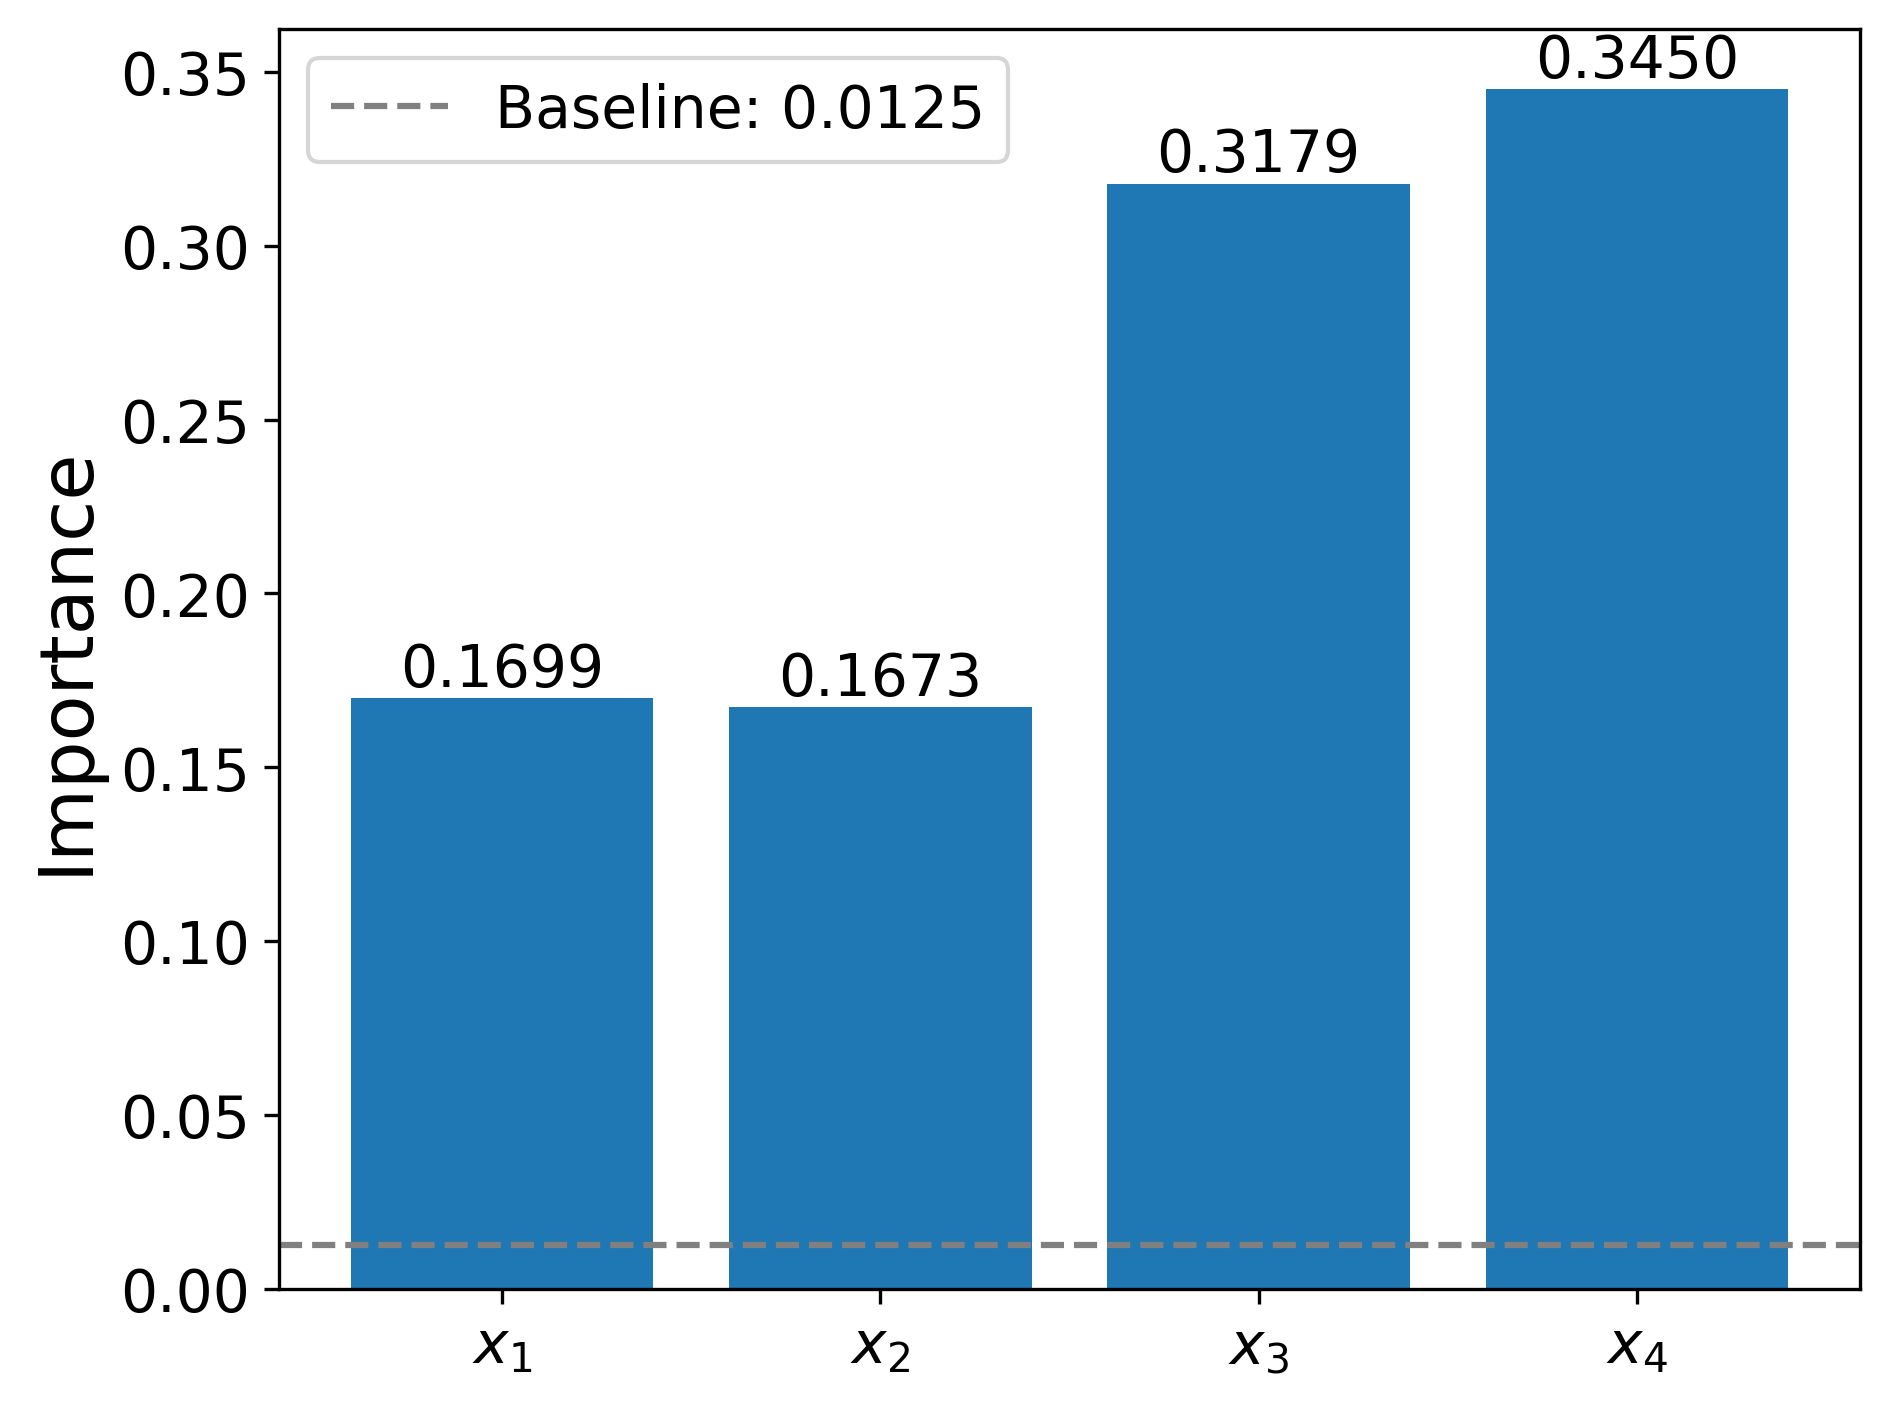

In [14]:
# Figure: learned importance
plot_learned_importance(
    scores=results["learned_importance_scores"],
    baseline=results["learned_importance_baseline"],
    features=features,
)
plot_learned_importance(
    scores=results["learned_importance_scores"],
    baseline=results["learned_importance_baseline"],
    features=features,
    to_file=FIGURES_DIR / f"{prefix}-learned_importance.pdf",
)

In [12]:
# Results
if rerun:
    with open(RESULTS_DIR / f"{prefix}-results.json", "w") as f:
        json.dump(results, f, indent=4)